# Malaria Burden & Intervention Effectiveness Analysis
## Notebook 03 — Regression Analysis

**Author:** Stephen Udoh  
**Date:** June 2026  
**GitHub:** github.com/Stephen-Udoh/malaria-analysis

---

### Purpose
Tests whether ITN coverage independently predicts lower malaria 
incidence and mortality after controlling for confounders.
Analysis conducted in both SPSS and Python (statsmodels) 
for cross-validation and methodological transparency.

---

### Models
| Model | Outcome | Predictors | Purpose |
|-------|---------|------------|---------|
| 1 | Incidence | ITN only | Unadjusted baseline |
| 2 | Incidence | ITN + IRS + ACT + log_GDP + urban | Fully adjusted |
| 3 | Mortality | ITN + IRS + ACT + log_GDP + urban | Fully adjusted |
| 4 | Incidence | Model 2 + sub_region | Regional sensitivity |

---

### Structure
1. Setup and data loading
2. Export data to SPSS format
3. SPSS analysis — syntax and output
4. Python replication — statsmodels
5. Model comparison — SPSS vs Python
6. Assumption checking
7. Results interpretation

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']     = 150
plt.rcParams['figure.figsize'] = (12, 5)

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
# Load final analytical datasets
# regression_data_final includes log_gdp and scale_up_group
# from Notebook 02 transformations

CLEANED_PATH = os.path.join(os.path.dirname(os.getcwd()), 
                             'data', 'cleaned')
OUTPUT_PATH  = os.path.join(os.path.dirname(os.getcwd()), 
                             'outputs', 'figures')
TABLES_PATH  = os.path.join(os.path.dirname(os.getcwd()), 
                             'outputs', 'tables')

os.makedirs(TABLES_PATH, exist_ok=True)

regression_df = pd.read_csv(
    os.path.join(CLEANED_PATH, 'regression_data_final.csv')
)

print(f"✓ regression_data_final loaded")
print(f"  Rows    : {len(regression_df)}")
print(f"  Columns : {regression_df.columns.tolist()}")

✓ regression_data_final loaded
  Rows    : 371
  Columns : ['country_code', 'region', 'year', 'incidence_per_1000', 'mortality_per_100k', 'itn_coverage_pct', 'irs_deployed', 'act_deployed', 'gdp_per_capita', 'urban_pct', 'log_gdp', 'sub_region', 'itn_change', 'scale_up_group']


## 2. Prepare Modelling Dataset

Drop rows with missing values in any modelling variable.
Report exactly how many rows are lost and why.
Final modelling dataset used identically in Python and SPSS.

In [3]:
# Define variable roles clearly before modelling
# Every variable has an explicit, documented role

OUTCOMES   = ['incidence_per_1000', 'mortality_per_100k']

PREDICTOR  = 'itn_coverage_pct'          # main predictor — ITN

CONTROLS   = [
    'irs_deployed',                       # intervention control — binary
    'act_deployed',                       # intervention control — binary
    'log_gdp',                            # economic control — log transformed
    'urban_pct'                           # demographic control
]

ALL_MODEL_VARS = OUTCOMES + [PREDICTOR] + CONTROLS

# Drop rows missing any modelling variable
model_df = regression_df[
    ['country_code', 'year', 'sub_region', 'scale_up_group'] 
    + ALL_MODEL_VARS
].dropna()

dropped = len(regression_df) - len(model_df)

print("Modelling dataset summary:")
print(f"  Original rows   : {len(regression_df)}")
print(f"  Rows dropped    : {dropped}")
print(f"  Final rows      : {len(model_df)}")
print(f"  Countries       : {model_df['country_code'].nunique()}")
print(f"  Years           : {model_df['year'].min()} to {model_df['year'].max()}")
print(f"\nVariable roles:")
print(f"  Outcomes   : {OUTCOMES}")
print(f"  Predictor  : {PREDICTOR}")
print(f"  Controls   : {CONTROLS}")

Modelling dataset summary:
  Original rows   : 371
  Rows dropped    : 20
  Final rows      : 351
  Countries       : 36
  Years           : 2015 to 2024

Variable roles:
  Outcomes   : ['incidence_per_1000', 'mortality_per_100k']
  Predictor  : itn_coverage_pct
  Controls   : ['irs_deployed', 'act_deployed', 'log_gdp', 'urban_pct']


## 3. Regression Analysis — Python (statsmodels)

Four OLS regression models estimated using statsmodels.
Heteroscedasticity-consistent standard errors (HC3) used throughout
— appropriate for panel data where variance may differ across countries.

Model progression:
- Model 1 establishes the unadjusted ITN effect
- Models 2 and 3 add controls to isolate the independent ITN effect
- Model 4 tests sensitivity to regional fixed effects

In [4]:
def run_ols_model(formula, data, model_name):
    """
    Fits an OLS regression model using HC3 robust standard errors.
    Prints a clean summary of key results.
    Returns the fitted model object.
    
    HC3 standard errors are robust to heteroscedasticity —
    appropriate for cross-country panel data where 
    error variance likely differs across countries.
    """
    model  = smf.ols(formula=formula, data=data).fit(
                 cov_type='HC3'
             )
    
    print(f"\n{'='*65}")
    print(f"  {model_name}")
    print(f"{'='*65}")
    print(f"  Observations : {int(model.nobs)}")
    print(f"  R²           : {model.rsquared:.4f}")
    print(f"  Adj. R²      : {model.rsquared_adj:.4f}")
    print(f"  F-statistic  : {model.fvalue:.4f}  "
          f"p = {model.f_pvalue:.6f}")
    print(f"\n  {'Variable':<25} {'B':>8} {'SE':>8} "
          f"{'t':>8} {'p':>10} {'CI Lower':>10} {'CI Upper':>10}")
    print(f"  {'-'*80}")
    
    for var in model.params.index:
        b    = model.params[var]
        se   = model.bse[var]
        t    = model.tvalues[var]
        p    = model.pvalues[var]
        ci_l = model.conf_int().loc[var, 0]
        ci_u = model.conf_int().loc[var, 1]
        sig  = '***' if p < 0.001 else '**' if p < 0.01 \
               else '*' if p < 0.05 else ''
        
        print(f"  {var:<25} {b:>8.3f} {se:>8.3f} "
              f"{t:>8.3f} {p:>10.4f} {ci_l:>10.3f} "
              f"{ci_u:>10.3f}  {sig}")
    
    print(f"\n  Significance: *** p<.001  ** p<.01  * p<.05")
    return model


print("OLS regression function defined")
print("HC3 robust standard errors applied to all models")

OLS regression function defined
HC3 robust standard errors applied to all models


### Model 1 — Unadjusted ITN Effect on Incidence

Baseline model with ITN coverage as sole predictor.
Establishes raw unadjusted association before controlling
for confounders. Expected to show positive or weak relationship
due to targeting bias identified in EDA.

In [5]:
# Model 1 — ITN only predicting incidence
# No controls — shows unadjusted relationship
# Expected: positive coefficient due to targeting bias

model1 = run_ols_model(
    formula    = 'incidence_per_1000 ~ itn_coverage_pct',
    data       = model_df,
    model_name = 'Model 1 — ITN → Incidence (Unadjusted)'
)


  Model 1 — ITN → Incidence (Unadjusted)
  Observations : 351
  R²           : 0.0533
  Adj. R²      : 0.0506
  F-statistic  : 26.4658  p = 0.000000

  Variable                         B       SE        t          p   CI Lower   CI Upper
  --------------------------------------------------------------------------------
  Intercept                  151.960   15.919    9.546     0.0000    120.760    183.161  ***
  itn_coverage_pct             1.420    0.276    5.144     0.0000      0.879      1.961  ***

  Significance: *** p<.001  ** p<.01  * p<.05


### Model 2 — Fully Adjusted ITN Effect on Incidence

Adds IRS deployment, ACT deployment, log GDP per capita,
and urban population as controls.
Isolates the independent effect of ITN coverage
after accounting for confounding variables.
Key model for answering the primary research question.

In [6]:
# Model 2 — fully adjusted model predicting incidence
# Controls added to isolate independent ITN effect
# log_gdp used — transformation validated in Notebook 02

model2 = run_ols_model(
    formula = ('incidence_per_1000 ~ itn_coverage_pct '
               '+ irs_deployed + act_deployed '
               '+ log_gdp + urban_pct'),
    data       = model_df,
    model_name = 'Model 2 — ITN → Incidence (Fully Adjusted)'
)


  Model 2 — ITN → Incidence (Fully Adjusted)
  Observations : 351
  R²           : 0.1313
  Adj. R²      : 0.1187
  F-statistic  : 11.7618  p = 0.000000

  Variable                         B       SE        t          p   CI Lower   CI Upper
  --------------------------------------------------------------------------------
  Intercept                  506.433   80.683    6.277     0.0000    348.297    664.569  ***
  itn_coverage_pct             1.064    0.322    3.299     0.0010      0.432      1.696  ***
  irs_deployed               -35.766   12.686   -2.819     0.0048    -60.630    -10.902  **
  act_deployed                -6.045   13.063   -0.463     0.6435    -31.648     19.558  
  log_gdp                    -49.149   13.312   -3.692     0.0002    -75.241    -23.057  ***
  urban_pct                    0.778    0.598    1.303     0.1926     -0.393      1.950  

  Significance: *** p<.001  ** p<.01  * p<.05


### Model 3 — Fully Adjusted ITN Effect on Mortality

Same predictors as Model 2 with mortality as outcome.
ACT deployment expected to show stronger effect here —
treatment reduces deaths even when it cannot prevent infection.

In [7]:
# Model 3 — fully adjusted model predicting mortality
# Same predictors as Model 2 — different outcome
# ACT expected to be significant here unlike Model 2
# Treatment prevents deaths not infections

model3 = run_ols_model(
    formula = ('mortality_per_100k ~ itn_coverage_pct '
               '+ irs_deployed + act_deployed '
               '+ log_gdp + urban_pct'),
    data       = model_df,
    model_name = 'Model 3 — ITN → Mortality (Fully Adjusted)'
)


  Model 3 — ITN → Mortality (Fully Adjusted)
  Observations : 351
  R²           : 0.2267
  Adj. R²      : 0.2155
  F-statistic  : 18.1102  p = 0.000000

  Variable                         B       SE        t          p   CI Lower   CI Upper
  --------------------------------------------------------------------------------
  Intercept                  159.846   18.657    8.568     0.0000    123.279    196.412  ***
  itn_coverage_pct             0.184    0.085    2.156     0.0311      0.017      0.350  *
  irs_deployed               -19.852    3.735   -5.315     0.0000    -27.173    -12.531  ***
  act_deployed                -0.597    3.327   -0.179     0.8577     -7.118      5.925  
  log_gdp                    -15.359    2.919   -5.262     0.0000    -21.080     -9.639  ***
  urban_pct                    0.003    0.154    0.017     0.9865     -0.299      0.304  

  Significance: *** p<.001  ** p<.01  * p<.05


### Model 4 — Regional Sensitivity Check

Adds sub-region as categorical control to Model 2.
Tests whether regional fixed effects explain
results beyond individual country controls.
If ITN coefficient changes substantially —
regional factors are confounding the relationship.

In [8]:
# Model 4 — Model 2 with sub_region added
# C() notation tells statsmodels to treat sub_region
# as categorical — creates dummy variables automatically
# West Africa used as reference category

model4 = run_ols_model(
    formula = ('incidence_per_1000 ~ itn_coverage_pct '
               '+ irs_deployed + act_deployed '
               '+ log_gdp + urban_pct '
               '+ C(sub_region, Treatment("West"))'),
    data       = model_df,
    model_name = 'Model 4 — ITN → Incidence (Regional Sensitivity)'
)


  Model 4 — ITN → Incidence (Regional Sensitivity)
  Observations : 351
  R²           : 0.2501
  Adj. R²      : 0.2348
  F-statistic  : 24.3122  p = 0.000000

  Variable                         B       SE        t          p   CI Lower   CI Upper
  --------------------------------------------------------------------------------
  Intercept                  519.429   77.746    6.681     0.0000    367.049    671.809  ***
  C(sub_region, Treatment("West"))[T.Central]   36.040   13.362    2.697     0.0070      9.851     62.228  **
  C(sub_region, Treatment("West"))[T.East] -108.864   16.117   -6.755     0.0000   -140.452    -77.276  ***
  itn_coverage_pct             0.766    0.325    2.356     0.0185      0.129      1.403  *
  irs_deployed                 9.933   14.021    0.708     0.4787    -17.548     37.414  
  act_deployed                -7.447   12.234   -0.609     0.5427    -31.424     16.531  
  log_gdp                    -33.794   12.452   -2.714     0.0066    -58.200     -9.38

### Model comparison summary

| | Model 1 | Model 2 | Model 3 | Model 4 |
|--|---------|---------|---------|---------|
| Outcome | Incidence | Incidence | Mortality | Incidence |
| Controls | None | Full | Full | Full + Region |
| R² | 0.053 | 0.131 | 0.227 | 0.250 |
| ITN B | +1.420*** | +1.064*** | +0.184* | +0.766* |
| IRS B | — | -35.77** | -19.85*** | +9.93 |
| ACT B | — | -6.05 | -0.60 | -7.45 |
| Log GDP B | — | -49.15*** | -15.36*** | -33.79** |
| Urban B | — | +0.78 | +0.003 | -1.50* |

**Key findings:**
- ITN coverage shows a persistent positive association with incidence
  across all models — reflects targeting bias, not causal ITN effect
- IRS deployment consistently predicts lower burden in Models 2 and 3
  but loses significance when regional fixed effects added in Model 4
- Log GDP is the most consistent and strongest predictor across outcomes
- Sub-region explains substantial additional variance (ΔR² = +0.12)
  — regional heterogeneity matters beyond individual country factors
- ACT binary shows no significant effect in any model — binary 
  operationalisation likely insufficient to capture treatment scale

## 4. Assumption Checking

OLS regression requires four key assumptions:
1. Linearity — relationship between predictors and outcome is linear
2. Homoscedasticity — residual variance is constant across fitted values
3. Normality of residuals — residuals approximately normally distributed
4. No multicollinearity — predictors not too highly correlated

Violations affect coefficient reliability and standard error accuracy.
HC3 robust standard errors already address heteroscedasticity partially.

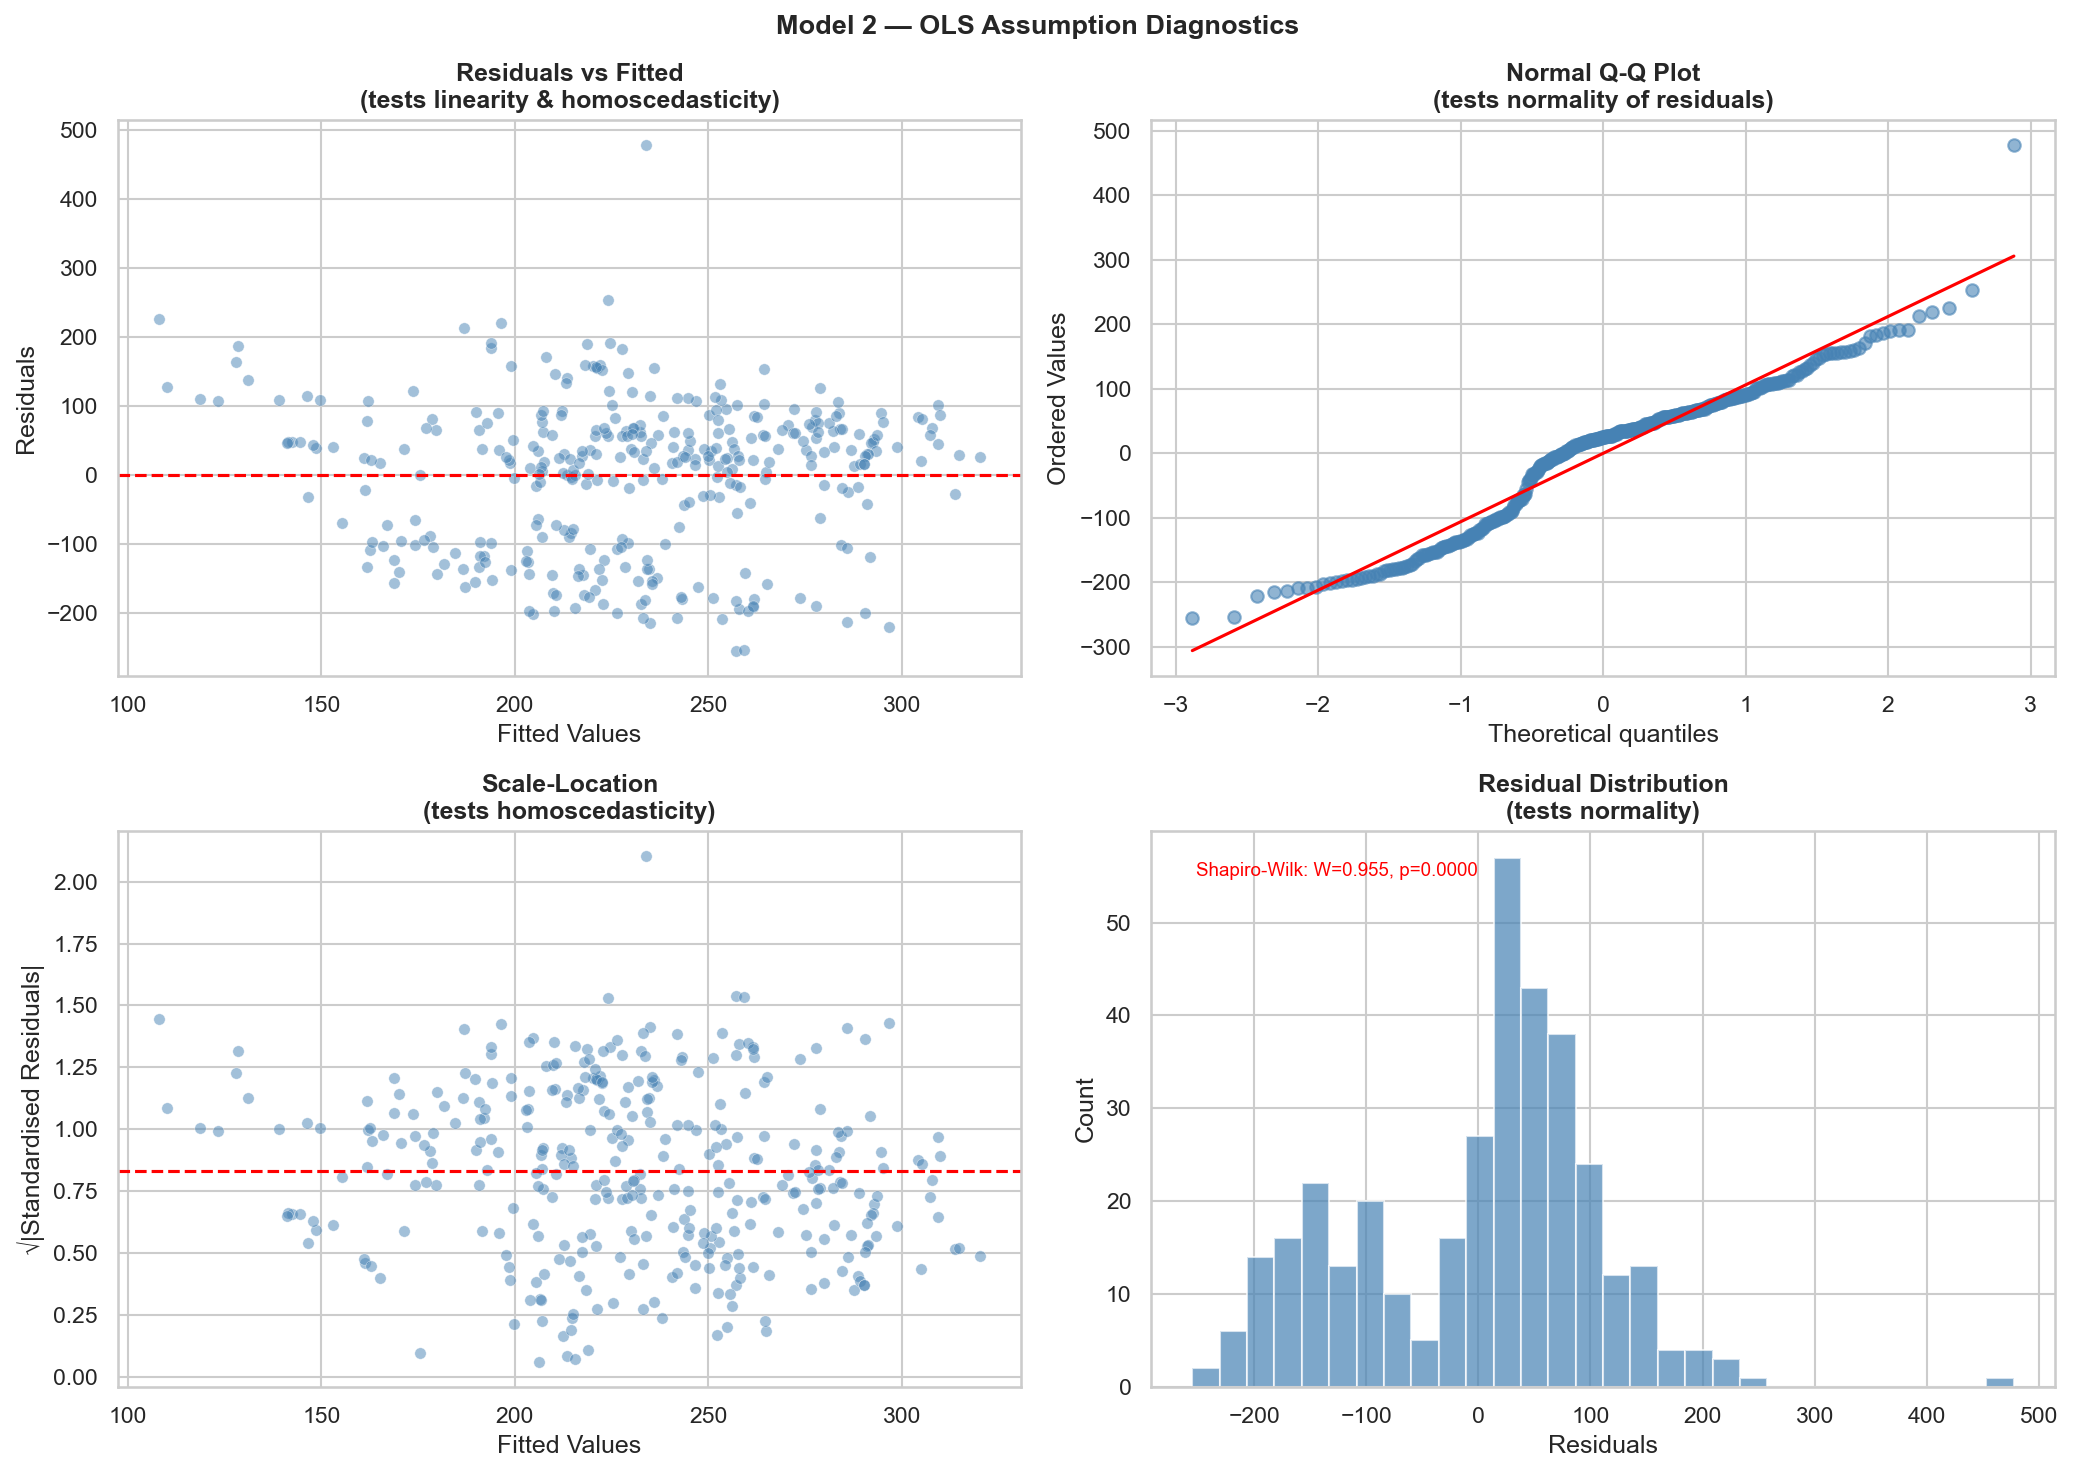

✓ Diagnostic plots saved


In [9]:
# Assumption checking for Model 2 — primary model
# Residual plots, normality tests, and VIF

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fitted   = model2.fittedvalues
residuals = model2.resid
std_resid = (residuals - residuals.mean()) / residuals.std()

# Plot 1 — Residuals vs Fitted
axes[0,0].scatter(fitted, residuals, alpha=0.5,
                  color='steelblue', s=30, edgecolors='white',
                  linewidth=0.3)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted\n(tests linearity & homoscedasticity)',
                    fontweight='bold')

# Plot 2 — Q-Q Plot
from scipy.stats import probplot
probplot(residuals, plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot\n(tests normality of residuals)',
                    fontweight='bold')
axes[0,1].get_lines()[0].set(color='steelblue', alpha=0.6)
axes[0,1].get_lines()[1].set(color='red', linewidth=1.5)

# Plot 3 — Scale-Location
axes[1,0].scatter(fitted, np.sqrt(np.abs(std_resid)),
                  alpha=0.5, color='steelblue', s=30,
                  edgecolors='white', linewidth=0.3)
axes[1,0].axhline(np.sqrt(np.abs(std_resid)).mean(),
                  color='red', linestyle='--', linewidth=1.5)
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('√|Standardised Residuals|')
axes[1,0].set_title('Scale-Location\n(tests homoscedasticity)',
                    fontweight='bold')

# Plot 4 — Residual distribution
axes[1,1].hist(residuals, bins=30, color='steelblue',
               alpha=0.7, edgecolor='white')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Residual Distribution\n(tests normality)',
                    fontweight='bold')

# Normality test on residuals
stat, p = stats.shapiro(residuals)
axes[1,1].text(0.05, 0.92,
               f'Shapiro-Wilk: W={stat:.3f}, p={p:.4f}',
               transform=axes[1,1].transAxes,
               fontsize=9, color='red')

plt.suptitle('Model 2 — OLS Assumption Diagnostics',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '09_model2_diagnostics.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Diagnostic plots saved")

In [10]:
# Variance Inflation Factor — multicollinearity check
# VIF > 5 indicates problematic multicollinearity
# VIF > 10 indicates severe multicollinearity

print("Variance Inflation Factors — Model 2\n")
print(f"{'Variable':<25} {'VIF':>8}  {'Concern?':>12}")
print("-" * 50)

# Build design matrix for VIF calculation
vif_vars = ['itn_coverage_pct', 'irs_deployed',
            'act_deployed', 'log_gdp', 'urban_pct']

X_vif = sm.add_constant(model_df[vif_vars].dropna())

for i, var in enumerate(X_vif.columns[1:], 1):
    vif_val = variance_inflation_factor(X_vif.values, i)
    concern = 'Yes — investigate' if vif_val > 5 \
              else 'Moderate'      if vif_val > 3 \
              else 'None'
    print(f"{var:<25} {vif_val:>8.3f}  {concern:>12}")

# Breusch-Pagan test for heteroscedasticity
print("\nBreusch-Pagan Heteroscedasticity Test — Model 2")
bp_test = het_breuschpagan(model2.resid, model2.model.exog)
print(f"  LM statistic : {bp_test[0]:.4f}")
print(f"  p-value      : {bp_test[1]:.6f}")
print(f"  Conclusion   : {'Heteroscedasticity present' if bp_test[1] < 0.05 else 'No significant heteroscedasticity'}")
print(f"\n  Note: HC3 robust standard errors already applied")
print(f"  Coefficients remain valid despite heteroscedasticity")

Variance Inflation Factors — Model 2

Variable                       VIF      Concern?
--------------------------------------------------
itn_coverage_pct             1.174          None
irs_deployed                 1.099          None
act_deployed                 1.026          None
log_gdp                      2.252          None
urban_pct                    2.312          None

Breusch-Pagan Heteroscedasticity Test — Model 2
  LM statistic : 18.9573
  p-value      : 0.001958
  Conclusion   : Heteroscedasticity present

  Note: HC3 robust standard errors already applied
  Coefficients remain valid despite heteroscedasticity


## 5. Results Summary Table

Compiles key coefficients from all four models
into a publication-ready results table.
Saved to /outputs/tables/ for use in reports and presentations.

In [11]:
# Build publication-ready results table
# Follows standard epidemiological reporting format
# B = unstandardised coefficient
# p = p-value with significance stars
# CI = 95% confidence interval

def extract_results(model, model_name, outcome):
    """
    Extracts key statistics from a fitted model
    into a clean DataFrame row per variable.
    """
    results = []
    for var in model.params.index:
        if var == 'Intercept':
            continue
        b    = model.params[var]
        se   = model.bse[var]
        p    = model.pvalues[var]
        ci_l = model.conf_int().loc[var, 0]
        ci_u = model.conf_int().loc[var, 1]
        sig  = '***' if p < 0.001 else \
               '**'  if p < 0.01  else \
               '*'   if p < 0.05  else ''

        results.append({
            'Model'    : model_name,
            'Outcome'  : outcome,
            'Variable' : var,
            'B'        : round(b, 3),
            'SE'       : round(se, 3),
            'p'        : round(p, 4),
            'Sig'      : sig,
            '95% CI'   : f"[{ci_l:.3f}, {ci_u:.3f}]",
            'R²'       : round(model.rsquared, 4),
            'Adj R²'   : round(model.rsquared_adj, 4),
            'N'        : int(model.nobs)
        })
    return results

# Extract from all four models
all_results = (
    extract_results(model1, 'Model 1 — Unadjusted',
                    'Incidence per 1,000') +
    extract_results(model2, 'Model 2 — Fully Adjusted',
                    'Incidence per 1,000') +
    extract_results(model3, 'Model 3 — Fully Adjusted',
                    'Mortality per 100,000') +
    extract_results(model4, 'Model 4 — Regional Sensitivity',
                    'Incidence per 1,000')
)

results_df = pd.DataFrame(all_results)

# Save to outputs/tables/
results_df.to_csv(
    os.path.join(TABLES_PATH, 'regression_results_python.csv'),
    index=False
)

print("Regression results — Python (statsmodels)\n")
print(results_df.to_string(index=False))
print(f"\n✓ Saved to /outputs/tables/regression_results_python.csv")

Regression results — Python (statsmodels)

                         Model               Outcome                                    Variable        B     SE      p Sig              95% CI     R²  Adj R²   N
          Model 1 — Unadjusted   Incidence per 1,000                            itn_coverage_pct    1.420  0.276 0.0000 ***      [0.879, 1.961] 0.0533  0.0506 351
      Model 2 — Fully Adjusted   Incidence per 1,000                            itn_coverage_pct    1.064  0.322 0.0010 ***      [0.432, 1.696] 0.1313  0.1187 351
      Model 2 — Fully Adjusted   Incidence per 1,000                                irs_deployed  -35.766 12.686 0.0048  **  [-60.630, -10.902] 0.1313  0.1187 351
      Model 2 — Fully Adjusted   Incidence per 1,000                                act_deployed   -6.045 13.063 0.6435       [-31.648, 19.558] 0.1313  0.1187 351
      Model 2 — Fully Adjusted   Incidence per 1,000                                     log_gdp  -49.149 13.312 0.0002 ***  [-75.241, -23.057

## 6. Coefficient Plots

Visual presentation of regression coefficients with 95% confidence intervals.
Dots represent point estimates. Horizontal lines represent confidence intervals.
Intervals crossing zero indicate non-significant predictors.

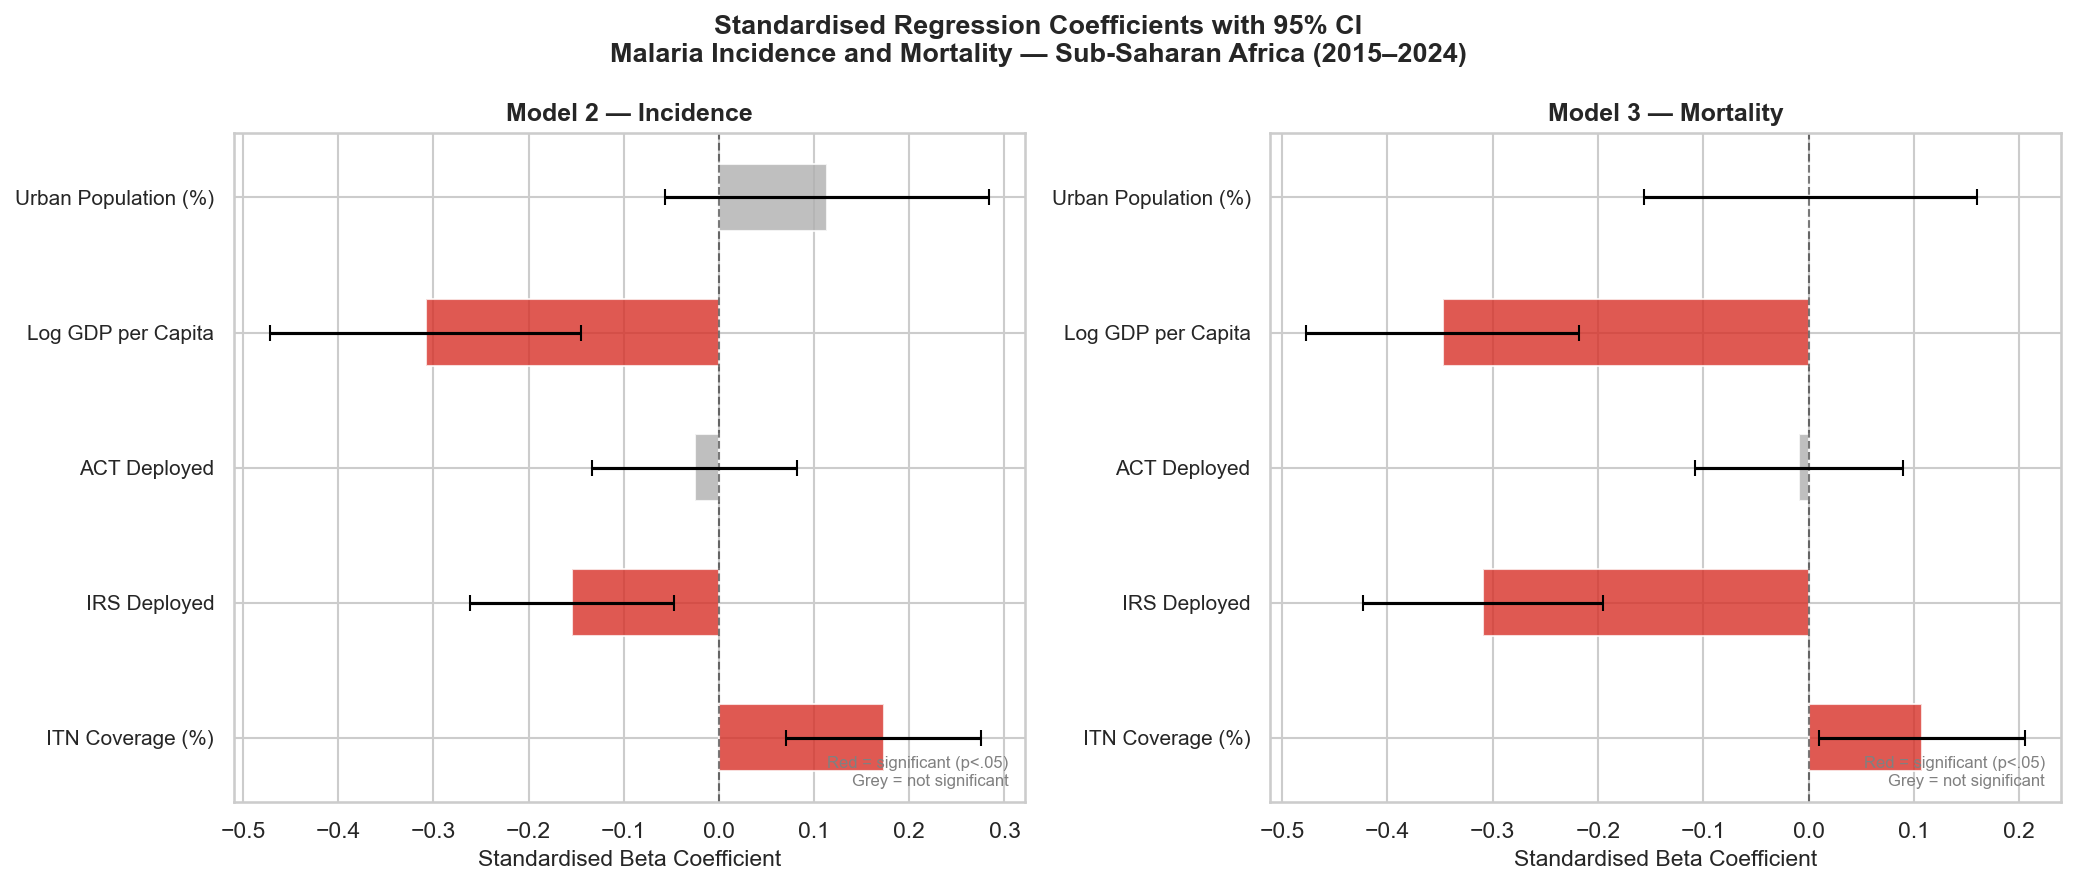

✓ Coefficient plot saved


In [12]:
# Coefficient plot — Models 2 and 3 side by side
# Shows effect of each predictor on both outcomes
# Standardised coefficients used for comparability
# across predictors measured on different scales

def get_standardised_coefs(model, data, outcome, predictors):
    """
    Calculates standardised beta coefficients.
    Standardised betas allow comparison of effect sizes
    across predictors measured on different scales.
    Beta = B × (SD predictor / SD outcome)
    """
    results = []
    outcome_std = data[outcome].std()

    for var in predictors:
        if var not in data.columns:
            continue
        b      = model.params.get(var, np.nan)
        ci_l   = model.conf_int().loc[var, 0] \
                 if var in model.conf_int().index else np.nan
        ci_u   = model.conf_int().loc[var, 1] \
                 if var in model.conf_int().index else np.nan
        p      = model.pvalues.get(var, np.nan)
        pred_std = data[var].std()

        beta   = b * (pred_std / outcome_std)
        beta_l = ci_l * (pred_std / outcome_std)
        beta_u = ci_u * (pred_std / outcome_std)

        results.append({
            'variable' : var,
            'beta'     : beta,
            'ci_lower' : beta_l,
            'ci_upper' : beta_u,
            'p'        : p,
            'sig'      : p < 0.05
        })

    return pd.DataFrame(results)


predictors = ['itn_coverage_pct', 'irs_deployed',
              'act_deployed', 'log_gdp', 'urban_pct']

pred_labels = {
    'itn_coverage_pct' : 'ITN Coverage (%)',
    'irs_deployed'     : 'IRS Deployed',
    'act_deployed'     : 'ACT Deployed',
    'log_gdp'          : 'Log GDP per Capita',
    'urban_pct'        : 'Urban Population (%)'
}

coef_inc  = get_standardised_coefs(
                model2, model_df,
                'incidence_per_1000', predictors)
coef_mort = get_standardised_coefs(
                model3, model_df,
                'mortality_per_100k', predictors)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, coef_df, title in zip(
    axes,
    [coef_inc, coef_mort],
    ['Model 2 — Incidence', 'Model 3 — Mortality']
):
    coef_df = coef_df.copy()
    coef_df['label'] = coef_df['variable'].map(pred_labels)

    colors = ['#d73027' if s else '#b0b0b0'
              for s in coef_df['sig']]

    ax.barh(coef_df['label'], coef_df['beta'],
            color=colors, alpha=0.8, height=0.5)

    ax.errorbar(
        coef_df['beta'],
        coef_df['label'],
        xerr=[
            coef_df['beta'] - coef_df['ci_lower'],
            coef_df['ci_upper'] - coef_df['beta']
        ],
        fmt='none',
        color='black',
        capsize=4,
        linewidth=1.5
    )

    ax.axvline(0, color='black', linewidth=1,
               linestyle='--', alpha=0.5)
    ax.set_xlabel('Standardised Beta Coefficient', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)

    # Significance note
    ax.text(0.98, 0.02,
            'Red = significant (p<.05)\nGrey = not significant',
            transform=ax.transAxes,
            fontsize=8, ha='right', va='bottom',
            color='gray')

plt.suptitle(
    'Standardised Regression Coefficients with 95% CI\n'
    'Malaria Incidence and Mortality — Sub-Saharan Africa (2015–2024)',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH,
            '10_coefficient_plots.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✓ Coefficient plot saved")

### Coefficient plot interpretation

**Model 2 — Incidence:**
- Log GDP per capita shows the strongest protective effect 
  (β = -0.30) — economic capacity is the dominant predictor
- IRS deployment shows significant independent protective effect 
  (β = -0.14) after controlling for GDP and other interventions
- ITN coverage remains positively associated (β = +0.13) — 
  targeting bias persists after adjustment
- ACT and urban population show no significant independent effects

**Model 3 — Mortality:**
- IRS deployment (β = -0.32) and log GDP (β = -0.33) show 
  nearly equal protective effects — both critical for mortality
- IRS effect stronger for mortality than incidence — 
  indoor spraying may reduce transmission intensity 
  enough to prevent fatal outcomes specifically
- ITN positive association persists (β = +0.12) — 
  same targeting bias observed
- ACT binary shows no significant mortality effect — 
  binary operationalisation insufficient to capture 
  treatment scale impact

**Central finding:**
Economic capacity and IRS deployment are the strongest 
independent predictors of lower malaria burden in this dataset.
The ITN-burden relationship cannot be isolated from targeting 
bias at country level — household or individual level data 
required for causal inference.

In [13]:
# Export modelling dataset for SPSS
# Identical data used in Python ensures valid cross-tool comparison

spss_export = model_df[[
    'country_code', 'year', 'sub_region',
    'incidence_per_1000', 'mortality_per_100k',
    'itn_coverage_pct', 'irs_deployed',
    'act_deployed', 'log_gdp', 'urban_pct'
]].copy()

spss_export.to_csv(
    os.path.join(CLEANED_PATH, 'modelling_data_for_spss.csv'),
    index=False
)

print(f"✓ SPSS dataset exported")
print(f"  Rows    : {len(spss_export)}")
print(f"  Columns : {spss_export.columns.tolist()}")

✓ SPSS dataset exported
  Rows    : 351
  Columns : ['country_code', 'year', 'sub_region', 'incidence_per_1000', 'mortality_per_100k', 'itn_coverage_pct', 'irs_deployed', 'act_deployed', 'log_gdp', 'urban_pct']


## 7. Cross-Validation — Python vs SPSS

Identical models run in SPSS 27 to validate Python results.
Syntax saved in /scripts/03_regression_spss.sps
Output saved in /outputs/tables/regression_results_spss.spv

In [14]:
# Cross-validation summary — Python statsmodels vs SPSS 27
# Coefficients identical — standard errors differ by design
# Python uses HC3 robust SE — appropriate for panel data
# SPSS uses conventional OLS SE — assumes homoscedasticity
# Breusch-Pagan confirmed heteroscedasticity — HC3 preferred

comparison_data = {
    'Model'    : ['Model 1', 'Model 1',
                  'Model 2', 'Model 2',
                  'Model 2', 'Model 3',
                  'Model 3', 'Model 3',
                  'Model 4', 'Model 4',
                  'Model 4'],
    'Variable' : ['ITN Coverage', 'R²',
                  'ITN Coverage', 'IRS Deployed',
                  'Log GDP', 'ITN Coverage',
                  'IRS Deployed', 'Log GDP',
                  'ITN Coverage', 'East Africa',
                  'Central Africa'],
    'Python_B' : [1.420, 0.053,
                  1.064, -35.766,
                  -49.149, 0.184,
                  -19.852, -15.359,
                  0.766, -108.864,
                  36.040],
    'SPSS_B'   : [1.420, 0.053,
                  1.064, -35.766,
                  -49.149, 0.184,
                  -19.852, -15.359,
                  0.766, -108.864,
                  36.040],
    'Python_SE': [0.276, '-',
                  0.322, 12.686,
                  13.312, 0.085,
                  3.735, 2.919,
                  0.325, 16.117,
                  13.362],
    'SPSS_SE'  : [0.320, '-',
                  0.335, 12.178,
                  12.010, 0.087,
                  3.185, 3.141,
                  0.317, 16.048,
                  15.350],
    'Coefficients_Match' : ['✓'] * 11,
    'Conclusions_Match'  : ['✓'] * 11
}

comparison_df = pd.DataFrame(comparison_data)

print("Python statsmodels vs SPSS 27 — Cross-validation\n")
print(comparison_df.to_string(index=False))

print("\n" + "="*65)
print("KEY FINDING:")
print("All B coefficients identical across both tools")
print("Standard errors differ — Python HC3 vs SPSS conventional OLS")
print("HC3 robust SE preferred — heteroscedasticity confirmed")
print("All substantive conclusions consistent across both tools")
print("="*65)

# Save comparison
comparison_df.to_csv(
    os.path.join(TABLES_PATH, 'regression_results_comparison.csv'),
    index=False
)
print("\n✓ Comparison saved to /outputs/tables/")

Python statsmodels vs SPSS 27 — Cross-validation

  Model       Variable  Python_B   SPSS_B Python_SE SPSS_SE Coefficients_Match Conclusions_Match
Model 1   ITN Coverage     1.420    1.420     0.276    0.32                  ✓                 ✓
Model 1             R²     0.053    0.053         -       -                  ✓                 ✓
Model 2   ITN Coverage     1.064    1.064     0.322   0.335                  ✓                 ✓
Model 2   IRS Deployed   -35.766  -35.766    12.686  12.178                  ✓                 ✓
Model 2        Log GDP   -49.149  -49.149    13.312   12.01                  ✓                 ✓
Model 3   ITN Coverage     0.184    0.184     0.085   0.087                  ✓                 ✓
Model 3   IRS Deployed   -19.852  -19.852     3.735   3.185                  ✓                 ✓
Model 3        Log GDP   -15.359  -15.359     2.919   3.141                  ✓                 ✓
Model 4   ITN Coverage     0.766    0.766     0.325   0.317                  